In [1]:
# 실습 준비 - 패키지 설치·폰트·GPU 확인·Chronos-2 내려받기
# [heavy]
#  Colab 에서만 chronos-forecasting 2.3.1 · holidays 0.103 을 설치합니다. 내 컴퓨터에서는 이미 깔린 버전을 씁니다.
#  교안의 수를 계산한 버전에 맞춰 고정합니다. 버전을 올리면 분위수와 공휴일 열이 달라질 수 있습니다.
#  numpy · pandas · pyarrow · torch · matplotlib 은 Colab 기본 버전을 그대로 씁니다.
import os, sys, math, time, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "chronos-forecasting==2.3.1", "holidays==0.103"], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트: Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 직접 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil
if IN_COLAB and shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색: 기준선=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다
FIGW = FIG_W      # 도우미가 밑줄을 빼고 FIGW 로 옮겨 적는 일이 있어 같은 값을 하나 더 둔다

try:
    import holidays
    _hol_ver = holidays.__version__
except ImportError:
    _hol_ver = "없음"
print("사용 폰트:", FONT, "| 색 팔레트 준비 완료 | holidays", _hol_ver)

# GPU 확인: 오늘 Chronos-2 예측은 모두 여기서 정한 DEVICE 에서 실행됩니다
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    _gpu = torch.cuda.get_device_properties(0)
    print(f"DEVICE : cuda | GPU {torch.cuda.get_device_name(0)} | 메모리 {_gpu.total_memory / 1e9:.1f} GB"
          f" | torch {torch.__version__}")
else:
    print(f"DEVICE : cpu | GPU 없음 | torch {torch.__version__}")
    print("GPU 가 연결되지 않았습니다. 메뉴 런타임 → 런타임 유형 변경 → GPU 를 고른 뒤 맨 위 셀부터 다시 실행합니다.")
    print("그대로 두면 같은 코드가 CPU 에서 실행되고, Chronos-2 예측이 GPU 보다 10배 넘게 오래 걸립니다.")

# Chronos-2 가중치(약 480MB)를 여기서 한 번 내려받아 둡니다. 준비 셀은 이 사본을 읽습니다.
#  내려받기가 끊기면 10초 쉬고 다시 시도하며, 세 번까지 합니다.
from huggingface_hub import snapshot_download
CHRONOS_ID = "amazon/chronos-2"
for _try in range(1, 4):
    try:
        snapshot_download(CHRONOS_ID, allow_patterns=["config.json", "model.safetensors"])
        print(f"Chronos-2 가중치 준비 완료: {CHRONOS_ID} ({_try}번째 시도)")
        break
    except Exception as _e:
        print(f"Chronos-2 내려받기 {_try}번째 실패: {type(_e).__name__}")
        if _try < 3:
            time.sleep(10)
else:   # 받지 못한 채 넘어가면 뒤 셀의 from_pretrained 가 내려받기 오류로 멈춘다. 여기서 멈춘다
    raise RuntimeError("Chronos-2 가중치를 세 번 모두 받지 못했습니다. LMS 면 이 셀을 다시 실행하고, 그래도 같으면"
                       " 강사에게 알립니다. Colab 이면 메뉴 런타임 → 런타임 다시 시작을 누른 뒤 이 셀부터 다시 실행합니다")

사용 폰트: DejaVu Sans | 색 팔레트 준비 완료 | holidays 0.103
DEVICE : cpu | GPU 없음 | torch 2.14.1+cpu
GPU 가 연결되지 않았습니다. 메뉴 런타임 → 런타임 유형 변경 → GPU 를 고른 뒤 맨 위 셀부터 다시 실행합니다.
그대로 두면 같은 코드가 CPU 에서 실행되고, Chronos-2 예측이 GPU 보다 10배 넘게 오래 걸립니다.


Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 509.98it/s]

Chronos-2 가중치 준비 완료: amazon/chronos-2 (1번째 시도)


In [4]:
font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

표 1 · 원점 5개의 채점 7일 가운데 공휴일인 날
  2025-08-13 · 공휴일 있는 주 · 08-15(금)
  2025-10-01 · 공휴일 있는 주 · 10-03(금) 10-05(일, 주말 공휴일) 10-06(월) 10-07(화)
  2025-12-10 · 공휴일 없는 주 · 없음
  2026-02-11 · 공휴일 있는 주 · 02-16(월) 02-17(화)
  2026-06-24 · 공휴일 없는 주 · 없음

표 2 · 후보 열과 값이 정해지는 때
  목표일 요일 · 달력으로 미리 정해진다
  공휴일 · 달력으로 미리 정해진다 (임시공휴일은 지정된 뒤부터)
  호선 · 역마다 하나로 정해져 날마다 같다
  목표일 하차 인원 · 그날이 지나야 기록된다
  실측 기온 · 그날이 지나야 기록된다
  기온 예보 · 예측 시점까지 발표된다


Loading weights: 100%|██████████| 170/170 [00:00<00:00, 423.39it/s]



표 3 · 공휴일이 있는 주와 없는 주의 평균 MASE, 계절 나이브와 Chronos-2 제로샷
  계절 나이브 : 공휴일 없는 두 주 0.445 · 공휴일 있는 세 주 2.767 · 원점 5개 평균 1.838
  Chronos-2 제로샷 : 공휴일 없는 두 주 0.271 · 공휴일 있는 세 주 2.763 · 원점 5개 평균 1.766


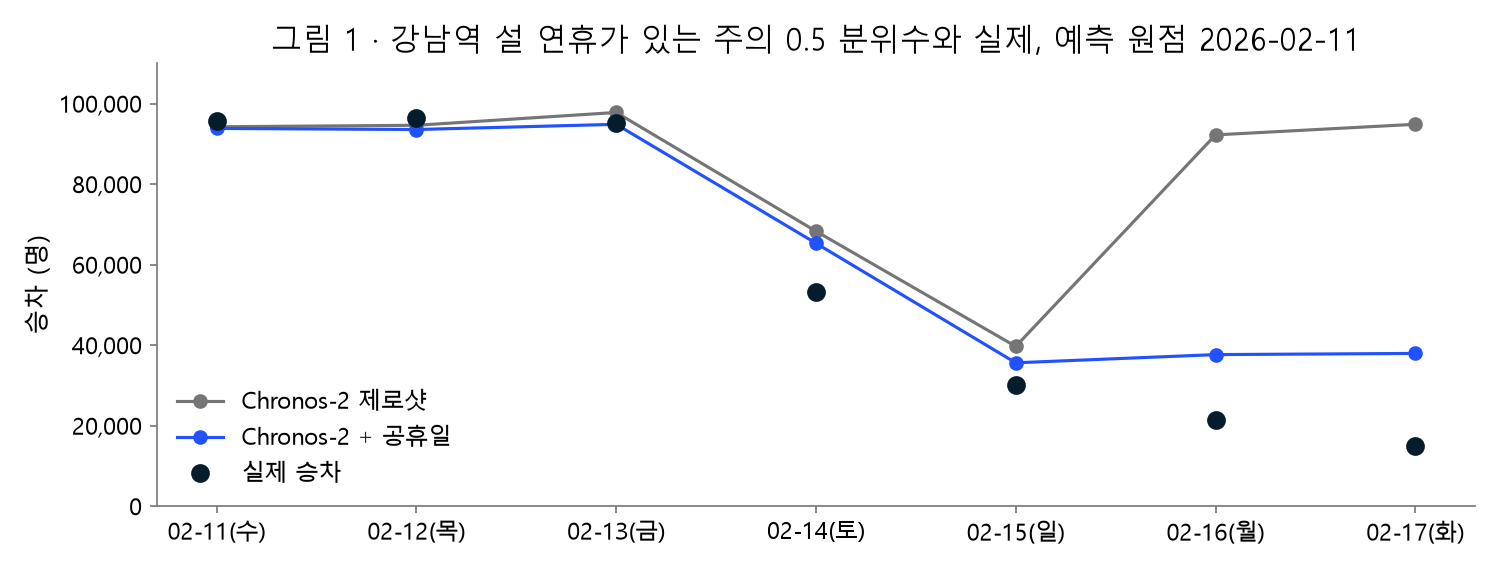

In [5]:
# 오늘의 준비 — 읽고 실행만 합니다
# 서울 지하철 100개 역으로 표 1 · 표 2 · 표 3 · 그림 1 을 만듭니다. GPU 에서 20초 안팎, CPU 에서 1분 안팎 걸립니다
# Chronos-2 를 불러오다 내려받기 오류(Hugging Face)가 나면 맨 위 설치 셀부터 다시 실행합니다
RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 지금까지와 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False, observed=True)[["board"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]
MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]
assert MAT.shape == (100, 4199) and STATIONS[0] == "2호선 강남"

H, CTX = 7, 512                               # 예측 7일 · Chronos-2 에 주는 과거 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]


def origin_ctx(origin):
    """원점 하나의 자료: 원점 열 번호(o), 원점 전날까지(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden, test_dates=DATES[o:o + H])


def hol_flags(dates):
    """날짜마다 한국 공휴일이면 1, 아니면 0 (holidays 0.103 KR, 주말 공휴일 포함)"""
    import holidays
    di = pd.DatetimeIndex(dates)
    kr = holidays.KR(years=sorted(set(di.year)))
    return np.array([1.0 if d in kr else 0.0 for d in di], dtype=np.float32)


HOL = hol_flags(DATES)

# 표 1: 원점마다 채점 7일 가운데 공휴일 열 값이 1 인 날(주말 공휴일 포함)
WEEKDAY = "월화수목금토일"
HOLIDAY_DATES = {}
print("표 1 · 원점 5개의 채점 7일 가운데 공휴일인 날")
for o in ORIGINS:
    c = origin_ctx(o)
    days = [d for d, h in zip(c["test_dates"], HOL[c["o"]:c["o"] + H]) if h == 1]
    HOLIDAY_DATES[o] = [f"{d:%m-%d}({WEEKDAY[d.weekday()]}" + (", 주말 공휴일)" if d.weekday() >= 5 else ")")
                        for d in days]
    group = "공휴일 없는 주" if o in PLAIN_ORIGINS else "공휴일 있는 주"
    print(f"  {o} · {group} · {' '.join(HOLIDAY_DATES[o]) or '없음'}")

# 표 2: 후보 열마다 값이 정해지는 때
CAND = pd.DataFrame({"col": ["목표일 요일", "공휴일", "호선", "목표일 하차 인원", "실측 기온", "기온 예보"],
                     "when": ["달력으로 미리 정해진다", "달력으로 미리 정해진다", "역마다 하나로 정해져 날마다 같다",
                              "그날이 지나야 기록된다", "그날이 지나야 기록된다", "예측 시점까지 발표된다"]})
print("\n표 2 · 후보 열과 값이 정해지는 때")
for col, when in zip(CAND["col"], CAND["when"]):
    print(f"  {col} · {when}" + (" (임시공휴일은 지정된 뒤부터)" if col == "공휴일" else ""))

# Chronos-2 를 DEVICE 에 올립니다. 끊기면 세 번까지 다시 시도합니다
from chronos import BaseChronosPipeline
PIPE = None
for _try in range(1, 4):
    try:
        PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
        break
    except Exception as _e:
        print(f"Chronos-2 불러오기 {_try}번째 실패: {type(_e).__name__}")
        time.sleep(5)


def chronos_frames(origin, holiday=True):
    """predict_df 에 넘길 (df, future_df). df 는 원점 전날까지 512일, future_df 는 채점 7일의 공휴일"""
    c = origin_ctx(origin)
    o, S = c["o"], MAT.shape[0]
    df = pd.DataFrame({"item_id": np.repeat(np.arange(S), CTX),
                       "timestamp": np.tile(DATES[o - CTX:o].values, S),
                       "target": MAT[:, o - CTX:o].ravel()})
    future_df = None
    if holiday:
        df["holiday"] = np.tile(HOL[o - CTX:o].astype(float), S)
        future_df = pd.DataFrame({"item_id": np.repeat(np.arange(S), H),
                                  "timestamp": np.tile(c["test_dates"].values, S),
                                  "holiday": np.tile(HOL[o:o + H].astype(float), S)})
    return df, future_df


def to_q(fc):
    """predict_df 결과 표를 역 순서대로 정렬해 100 x 7 x 9 분위수 배열로 모읍니다"""
    fc = fc.sort_values(["item_id", "timestamp"])
    return np.stack([fc[str(t)].to_numpy().reshape(-1, H) for t in QS], axis=-1)


# 표 3: 원점마다 역별 MASE 의 100개 역 평균, 계절 나이브(7일 전 같은 요일)와 Chronos-2 제로샷
Q_ZS, _mase, _cache = {}, {"계절 나이브": {}, "Chronos-2 제로샷": {}}, []
for o in ORIGINS:
    c = origin_ctx(o)
    fc = PIPE.predict_df(chronos_frames(o, holiday=False)[0], prediction_length=H, quantile_levels=QS)
    Q_ZS[o] = to_q(fc)
    _cache.append(fc.sort_values(["item_id", "timestamp"]).assign(origin=o))
    for name, point in [("계절 나이브", MAT[:, c["o"] - 7:c["o"]]), ("Chronos-2 제로샷", Q_ZS[o][..., 4])]:
        _mase[name][o] = float(np.mean(np.abs(c["test"] - point) / c["qden"][:, None]))
pd.concat(_cache)[["origin", "item_id", "timestamp"] + [str(t) for t in QS]].to_parquet("c2_zs_q.parquet")
GROUP_MASE = {name: (float(np.mean([m[o] for o in PLAIN_ORIGINS])), float(np.mean([m[o] for o in HOL_ORIGINS])),
                     float(np.mean([m[o] for o in ORIGINS]))) for name, m in _mase.items()}
print("\n표 3 · 공휴일이 있는 주와 없는 주의 평균 MASE, 계절 나이브와 Chronos-2 제로샷")
for name, (p, h, m) in GROUP_MASE.items():
    print(f"  {name} : 공휴일 없는 두 주 {p:.3f} · 공휴일 있는 세 주 {h:.3f} · 원점 5개 평균 {m:.3f}")

# 그림 1: 강남역 한 역만 공휴일 열을 입력해 예측하고, 제로샷·실제와 나란히 그립니다
c, _o = origin_ctx("2026-02-11"), "2026-02-11"
_df, _fdf = chronos_frames(_o, holiday=True)
SEOL_Y, SEOL_ZS = c["test"][0], Q_ZS[_o][0, :, 4]
SEOL_HOL = to_q(PIPE.predict_df(_df[_df.item_id == 0], future_df=_fdf[_fdf.item_id == 0],
                                prediction_length=H, quantile_levels=QS))[0, :, 4]
days = [f"{d:%m-%d}({WEEKDAY[d.weekday()]})" for d in c["test_dates"]]
fig, ax = plt.subplots(figsize=(FIG_W, 3.8))
ax.plot(days, SEOL_ZS, color=COL["회색"], marker="o", label="Chronos-2 제로샷")
ax.plot(days, SEOL_HOL, color=COL["파랑"], marker="o", label="Chronos-2 + 공휴일")
ax.plot(days, SEOL_Y, "o", color=COL["남색"], markersize=8, label="실제 승차")
ax.set_title("그림 1 · 강남역 설 연휴가 있는 주의 0.5 분위수와 실제, 예측 원점 2026-02-11")
ax.set_ylabel("승차 (명)")
ax.set_ylim(0, 110000)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.legend(loc="lower left", frameon=False)
plt.show()

# Chronos-2 의 df 에만 남긴 하차 열은 어떻게 쓰이나요?
예를 들어 df 에 역·날짜·승차·공휴일·하차 다섯 열을, future_df 에 역·날짜·공휴일 세 열을 넘긴다고 합시다.

A. 원점 전날까지 512일의 하차만 과거 공변량으로 쓰인다

원점 전날까지 512일의 하차만 과거 공변량으로 쓰입니다. 과거 표 df 에는 원점 전날까지 512일의 값만 있고, 채점 7일의 입력이 되는 것은 미래 입력 future_df 에 포함한 열뿐이기 때문입니다(이론 「1. 공변량 세 종류와 누수」 · 「2. 공휴일 열과 미래 입력」).

이 예의 future_df 에 있는 공변량은 공휴일 하나라, 채점 7일(원점부터 7일)의 입력이 되는 공변량도 공휴일 하나입니다. 하차는 df 의 512일 동안의 값만 승차와 함께 읽힙니다. 예측 시점에 이미 기록된 값이라 누수가 아닙니다.

채점 7일의 하차까지 읽혀 누수가 된다: 하차가 future_df 에도 있을 때의 일입니다. 미션 2 의 전임 담당자 코드가 그렇게 만들었습니다.
future_df 에 없는 열이라 오류가 난다: df 에만 있는 열은 오류 없이 과거 공변량으로 받아들여집니다. 오류는 반대로 future_df 에만 있고 df 에 없는 열이 있을 때 납니다(「future_df cannot contain columns not present in df」).
그래서 새 열을 추가할 때는 df 와 future_df 의 열 목록을 한 번씩 출력해, 예측 시점에 앞으로 7일 값을 모르는 열이 future_df 에 있지 않은지 봅니다.

핵심 키워드: df 에만 포함한 열은 과거 공변량, future_df 의 열은 채점 7일의 입력, 추가하기 전에 두 표의 열 목록 확인

# 공변량을 추가해 평균이 좋아진 모델을 모든 주에 쓸까요?
예를 들어 공변량을 추가하기 전 → 추가한 뒤 MASE 가 원점 5개 평균 1.8 → 0.8, 공휴일 없는 두 주 0.30 → 0.35, 공휴일 있는 세 주 2.8 → 1.1 로 바뀌었다고 합시다.

B. 평일 공휴일이 있는 주는 공변량을 넣은 모델을 쓰고, 공휴일 없는 주는 평균 하나로 정하지 않고 따로 따진다

평일 공휴일이 있는 주는 공변량을 추가한 모델을 쓰고, 공휴일 없는 주는 따로 따집니다. 공휴일 있는 세 주는 1.7 줄어 0.077 보다 크고, 공휴일 없는 두 주의 차이 0.05 는 0.077 보다 작아 평균으로는 어느 모델이 더 낫다고 할 수 없기 때문입니다.

시드 범위 0.077 은 MLP(MSE 손실)를 시드 0～4 로 다시 학습했을 때 원점 5개 평균 MASE 가 오간 범위, 1.848 − 1.771 입니다. 두 모델의 평균 MASE 차이가 0.077 보다 작으면 차이가 있다고 보지 않습니다. 그래서 공휴일 없는 주에 어느 모델을 쓸지는 평균의 차이가 아닌 다른 근거(역마다 비교한 수, 모델 둘을 관리하는 비용)로 따로 따집니다.

가정한 값으로 원점 5개 평균을 다시 구하면 (2 × 0.30 + 3 × 2.8) ÷ 5 = 9.0 ÷ 5 = 1.8, (2 × 0.35 + 3 × 1.1) ÷ 5 = 4.0 ÷ 5 = 0.8 입니다. 공휴일 있는 세 주는 2.8 − 1.1 = 1.7 줄어 평균을 3 × 1.7 ÷ 5 = 1.02 낮췄습니다. 공휴일 없는 두 주는 0.35 − 0.30 = 0.05 올라 평균을 2 × 0.05 ÷ 5 = 0.02 높였습니다. 줄어든 1.0 은 1.02 − 0.02 입니다.

평균이 절반 아래로 줄었으니 모든 주에 쓴다: 줄어든 1.0 은 공휴일 있는 세 주가 낮춘 1.02 에서 왔습니다. 평균 하나만 보면 공휴일 없는 주에서 두 모델을 비교하지 않고 정하게 됩니다.
공휴일 없는 두 주가 나빠졌으니 공변량을 모든 주에서 뺀다: 0.05 는 0.077 보다 작아 「나빠졌다」고도 보지 않습니다. 이 보기를 고르면 공휴일 있는 세 주에서 1.7 줄어든 오차까지 버립니다.
그래서 평가표에는 공휴일 없는 두 주와 공휴일 있는 세 주의 MASE 를 나란히 적고, 평일 공휴일이 있는 주와 없는 주에 쓸 모델을 따로 정합니다.

핵심 키워드: 평균이 줄어든 주 확인, 평균 MASE 차이는 시드 범위 0.077 과 비교한다, 차이가 작으면 공휴일 유무로 나눠 따진다

# 설 두 날의 Chronos-2 + 공휴일 예측
「오늘의 준비」 셀을 실행하면 나오는 「그림 1 · 강남역 설 연휴가 있는 주의 0.5 분위수와 실제, 예측 원점 2026-02-11」을 봅니다. 공휴일 열을 입력한 뒤 2월 16일·17일 예측은 어디까지 내려왔나요?

C. 크게 내려왔지만 두 날 모두 실제보다 높다

크게 내려왔지만 이틀 모두 실제보다 높습니다. 그림 1 에서 파란 선(Chronos-2 + 공휴일)은 이틀 모두 약 3.8만 명인데, 남색 점(실제 승차)은 21,453명·14,973명이기 때문입니다.

세 높이를 날마다 비교합니다. 2월 16일(월)은 회색 선(제로샷) 약 9.2만 명, 파란 선 약 3.8만 명, 실제 21,453명입니다. 2월 17일(화)은 회색 선 약 9.5만 명, 파란 선 약 3.8만 명, 실제 14,973명입니다. 공휴일 열을 입력하자 이틀 모두 5만 명 넘게 내려왔습니다. 파란 선은 교안 환경에서 37,627명·37,919명이라, 실제보다 37,627 − 21,453 = 16,174명, 37,919 − 14,973 = 22,946명(약 1.6만·2.3만 명) 높고 실제의 약 1.8배·2.5배입니다.

두 날 모두 실제 승차 가까이까지 내려왔다: 크게 내려온 것만 보고 실제와 남은 차이를 놓친 것입니다. 남은 차이가 이틀 모두 1.6만 명이 넘습니다.
제로샷과 거의 같은 높이에 머물렀다: 회색 선과 파란 선을 바꿔 읽은 것입니다. 9만 명대에 머문 회색 선이 평일처럼 예측한 제로샷입니다.
그래서 설 연휴가 있는 주도 Chronos-2 + 공휴일의 예측을 쓰고, 설 연휴 평일 이틀만 계절 나이브 예측 × 지난해 같은 날의 비로 바꿉니다(이론 「2. 공휴일 열과 미래 입력」 · 「3. 서울 지하철 100개 역 결과」). 공휴일 열은 값이 0 과 1 뿐이라 그날이 설 연휴인지 광복절인지 구별되지 않기 때문입니다.

핵심 키워드: 크게 내려왔지만 실제보다 높다, 공휴일 열로는 어느 연휴인지 구별되지 않는다, 설 연휴 평일 이틀만 지난해 같은 날의 비로

# 공휴일 없는 두 주에서 Chronos-2 + 공휴일과 비교할 모델
「오늘의 준비」 셀을 실행하면 나오는 「표 3 · 공휴일이 있는 주와 없는 주의 평균 MASE, 계절 나이브와 Chronos-2 제로샷」을 봅니다. Chronos-2 + 공휴일을 공휴일 없는 주에도 쓸지 정하려면, 공휴일 없는 두 주에서 그 모델의 MASE 를 어느 모델과 비교해야 할까요?

A. 제로샷과 계절 나이브 둘 다: 두 모델과의 MASE 차를 각각 0.077 과 비교한다

제로샷과 계절 나이브 둘 다와 비교합니다. Chronos-2 + 공휴일은 먼저 계절 나이브 0.445 보다 MASE 가 0.077 넘게 낮아야 쓸 수 있고, 이미 쓰는 제로샷 0.271 보다도 0.077 넘게 낮아야 제로샷 대신 쓸 까닭이 되기 때문입니다(이론 「3. 서울 지하철 100개 역 결과」).

두 조건은 묻는 것이 다릅니다. 계절 나이브와의 차이는 이 모델을 쓸 수 있는지를, 제로샷과의 차이는 쓰던 제로샷을 이 모델로 바꿀지를 묻습니다. 표 3 의 공휴일 없는 두 주는 계절 나이브 0.445, 제로샷 0.271 입니다. 제로샷은 0.445 − 0.271 = 0.174 낮아 첫째 조건을 이미 채웁니다. 그래서 Chronos-2 + 공휴일이 계절 나이브보다 낮다는 것만으로는 제로샷 대신 쓸 까닭이 되지 않습니다.

계절 나이브만: Chronos-2 + 공휴일이 계절 나이브보다 0.077 넘게 낮아도, 이미 쓰는 제로샷보다 더 빗나갈 수 있습니다.
원점 5개 평균만: 표 3 에서 제로샷의 원점 5개 평균은 계절 나이브보다 1.838 − 1.766 = 0.072 낮아, 0.077 보다 작습니다. 나눠서 보면 공휴일 없는 두 주는 0.174 낮고, 공휴일 있는 세 주는 2.767 − 2.763 = 0.004 라 같다고 봅니다. 평균의 0.072 가운데 2 × 0.174 ÷ 5 ≈ 0.070 이 공휴일 없는 두 주에서 왔습니다. 평균 하나로는 공휴일이 있는 주와 없는 주가 모두 낮아졌는지 알 수 없습니다.
제로샷보다 0.077 넘게 낮으면 계절 나이브보다도 저절로 0.077 넘게 낮습니다. 그래도 평가표에는 두 차이를 함께 적습니다. 제로샷과의 차이가 0.077 보다 작을 때는, 계절 나이브와의 차이가 공휴일 없는 주에도 이 모델을 쓸 수 있는지 따질 근거가 되기 때문입니다.

핵심 키워드: 공휴일 없는 두 주는 제로샷과 계절 나이브 둘 다와 비교한다, 평균 MASE 차이는 시드 범위 0.077 과 비교한다, 평균이 낮아도 공휴일이 있는 주와 없는 주가 모두 낮은 것은 아니다

# future_df 에 넣을 열
「오늘의 준비」 셀을 실행하면 나오는 「표 2 · 후보 열과 값이 정해지는 때」를 봅니다. future_df 에 포함해도 누수가 아닌 열만 모은 것은 무엇인가요?

B. 목표일 요일, 공휴일

목표일 요일과 공휴일입니다. future_df 에는 예측 시점에 채점 7일의 값을 이미 아는 열만 포함하는데, 표 2 에서 두 열이 「달력으로 미리 정해진다」이기 때문입니다(이론 「1. 공변량 세 종류와 누수」).

표 2 의 여섯 열을 예측 시점 기준으로 나누면 이렇습니다. 목표일 요일·공휴일은 달력으로 미리 정해져 7일 값을 채울 수 있습니다. 목표일 하차 인원·실측 기온은 「그날이 지나야 기록된다」라 예측 시점에는 7일 값을 모릅니다. 기온 예보는 그때까지 발표되는 값이라 포함할 수 있습니다. 호선은 역마다 하나로 정해져 7일 값을 미리 알아 누수는 아니지만, 날마다 같은 값이라 7일 가운데 어느 날이 다른지에 대한 정보는 없습니다.

공휴일, 목표일 하차 인원: 하차 인원은 그날이 지나야 기록됩니다. 백테스트 파일에는 지난날의 하차가 기록돼 있어 표가 막힘 없이 만들어지지만, 그 점수는 실제로 예측할 때는 얻을 수 없습니다. 미션 2 의 전임 담당자 코드가 이 경우입니다.
목표일 요일, 실측 기온: 실측 기온도 그날이 지나야 기록됩니다. 기온을 쓰고 싶다면 예측 시점까지 발표된 기온 예보를 입력합니다. 실측을 입력해 얻은 점수는 시계열 과목에서 배운 사후 예측(예측할 기간의 실제 공변량 값을 알고 낸 예측)의 점수입니다. 이 점수는 실제로 예측할 때의 오차로 볼 수 없습니다.
그래서 새 열을 제안할 때는 표 2 처럼 「값이 정해지는 때」를 열마다 먼저 적습니다.

핵심 키워드: future_df 는 예측 시점에 7일 값을 아는 열만, 하차·실측 기온은 과거 공변량, 기온은 예보로

In [6]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 이름을 직접 만듭니다
#  자료를 다시 불러오고 Chronos-2 를 DEVICE 에 올립니다. 제로샷 분위수는 「오늘의 준비」 셀이 남긴
#  c2_zs_q.parquet 를 읽고, 그 파일이 없으면 여기서 다시 예측합니다(GPU 몇 초, CPU 30초 안팎)
RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 지금까지와 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False, observed=True)[["board"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]
MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]

H, CTX = 7, 512                               # 예측 7일 · Chronos-2 에 주는 과거 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]                 # 공휴일 없는 두 주: 채점 7일에 평일 공휴일이 없다
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]     # 공휴일 있는 세 주: 채점 7일에 평일 공휴일이 있다


def origin_ctx(origin):
    """원점 하나의 자료: 원점 열 번호(o), 원점 전날까지(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)   # 원점 전날까지로 계산한 분모
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden, test_dates=DATES[o:o + H])


def hol_flags(dates):
    """날짜마다 한국 공휴일이면 1, 아니면 0 (holidays 0.103 KR, 주말 공휴일 포함)"""
    import holidays
    di = pd.DatetimeIndex(dates)
    kr = holidays.KR(years=sorted(set(di.year)))
    return np.array([1.0 if d in kr else 0.0 for d in di], dtype=np.float32)


HOL = hol_flags(DATES)


def score(y, pred, qden):
    """MASE(역별 MASE 의 100개 역 평균)와 RMSE(명)를 dict 로 돌려줍니다. y·pred 는 100 x 7"""
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    return dict(mase=float(np.mean(np.abs(y - pred) / np.asarray(qden)[:, None])),
                rmse=float(np.sqrt(np.mean((y - pred) ** 2))))


# Chronos-2 를 DEVICE 에 올립니다. 끊기면 세 번까지 다시 시도합니다
from chronos import BaseChronosPipeline
PIPE = None
for _try in range(1, 4):
    try:
        PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
        break
    except Exception as _e:
        print(f"Chronos-2 불러오기 {_try}번째 실패: {type(_e).__name__}")
        time.sleep(5)


def chronos_frames(origin, holiday=True):
    """predict_df 에 넘길 두 표 (df, future_df) 를 만듭니다

    df        : 100개 역 x 원점 전날까지 512일. item_id(MAT 의 행 번호 0~99) · timestamp · target(승차, 명)
                · holiday(공휴일 1/0). holiday=False 면 holiday 열이 없습니다
    future_df : 100개 역 x 채점 7일. item_id · timestamp · holiday(달력이 정한 공휴일). holiday=False 면 None
    채점 7일의 승차는 어느 표에도 없습니다
    """
    c = origin_ctx(origin)
    o, S = c["o"], MAT.shape[0]
    df = pd.DataFrame({"item_id": np.repeat(np.arange(S), CTX),
                       "timestamp": np.tile(DATES[o - CTX:o].values, S),
                       "target": MAT[:, o - CTX:o].ravel()})
    future_df = None
    if holiday:
        df["holiday"] = np.tile(HOL[o - CTX:o].astype(float), S)
        future_df = pd.DataFrame({"item_id": np.repeat(np.arange(S), H),
                                  "timestamp": np.tile(c["test_dates"].values, S),
                                  "holiday": np.tile(HOL[o:o + H].astype(float), S)})
    assert df["timestamp"].max() < pd.Timestamp(origin)   # 과거 표에는 원점 전날까지만
    return df, future_df


# 제로샷 분위수 Q_ZS: 원점 → 100 x 7 x 9. 파일이 있으면 읽고, 없으면 다시 예측합니다
Q_ZS = {}
if os.path.exists("c2_zs_q.parquet"):
    _z = pd.read_parquet("c2_zs_q.parquet")
    for o in ORIGINS:
        _d = _z[_z["origin"] == o].sort_values(["item_id", "timestamp"])
        Q_ZS[o] = np.stack([_d[str(t)].to_numpy().reshape(-1, H) for t in QS], axis=-1)
else:
    for o in ORIGINS:
        _fc = PIPE.predict_df(chronos_frames(o, holiday=False)[0], prediction_length=H, quantile_levels=QS)
        _fc = _fc.sort_values(["item_id", "timestamp"])
        Q_ZS[o] = np.stack([_fc[str(t)].to_numpy().reshape(-1, H) for t in QS], axis=-1)
assert all(Q_ZS[o].shape == (100, H, len(QS)) for o in ORIGINS)

_df, _fdf = chronos_frames("2026-02-11")
print(f"행렬 : 승차 MAT {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일 · {DATES[0].date()} ~ {DATES[-1].date()}")
print(f"원점 5개 : 공휴일 없는 두 주 {' · '.join(PLAIN_ORIGINS)} / 공휴일 있는 세 주 {' · '.join(HOL_ORIGINS)}")
print(f"chronos_frames(원점) : df 열 {list(_df.columns)} {len(_df):,}행 · future_df 열 {list(_fdf.columns)} {len(_fdf)}행")
print(f"Q_ZS : 원점마다 역 x 7일 x 분위수 9개 {Q_ZS[ORIGINS[0]].shape} · Chronos-2 DEVICE {DEVICE}")
print("쓸 수 있는 이름 : ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS · H · CTX · PIPE"
      " · chronos_frames(origin, holiday=True) · origin_ctx(origin) · score(y, pred, qden) · Q_ZS"
      " · MAT · DATES · STATIONS · HOL")

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 448.40it/s]

행렬 : 승차 MAT 100개 역 x 4,199일 · 2015-01-01 ~ 2026-06-30
원점 5개 : 공휴일 없는 두 주 2025-12-10 · 2026-06-24 / 공휴일 있는 세 주 2025-08-13 · 2025-10-01 · 2026-02-11
chronos_frames(원점) : df 열 ['item_id', 'timestamp', 'target', 'holiday'] 51,200행 · future_df 열 ['item_id', 'timestamp', 'holiday'] 700행
Q_ZS : 원점마다 역 x 7일 x 분위수 9개 (100, 7, 9) · Chronos-2 DEVICE cpu
쓸 수 있는 이름 : ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS · H · CTX · PIPE · chronos_frames(origin, holiday=True) · origin_ctx(origin) · score(y, pred, qden) · Q_ZS · MAT · DATES · STATIONS · HOL


공휴일 있는 세 주 MASE(Chronos-2 + 공휴일) = 1.022
공휴일 없는 두 주 MASE(Chronos-2 + 공휴일) = 0.322
(참고) 제로샷: 공휴일 있는 세 주 2.763, 공휴일 없는 두 주 0.271  / 기준 0.077


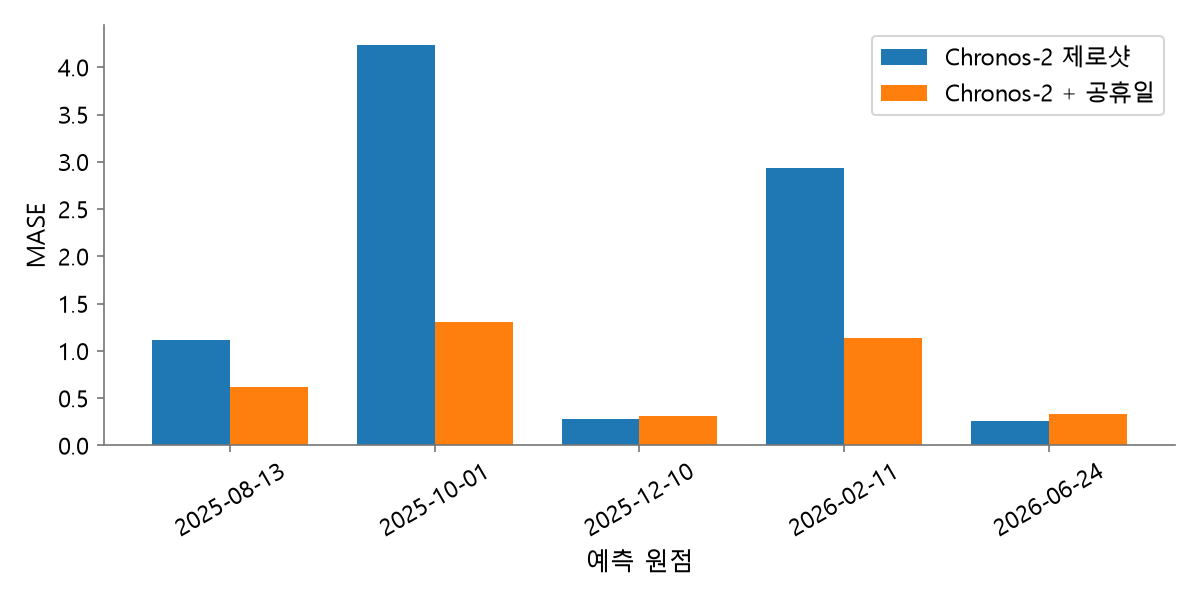

In [7]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → AI 튜터에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
# 시킬 일은 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 예시 프롬프트도 따옴표 안에 붙여 넣어야 채점됩니다
PROMPT = """
Chronos-2 + 공휴일은 공휴일 없는 두 주와 공휴일 있는 세 주에서 각각 제로샷보다 MASE를 비교할거야
미션1 준비 셀에 만들어둔 이름에 나열된 변수명은 그대로 사용해
1. 공휴일있는 세 주 MASE(Chronos-2 + 공휴일): 소수 셋째자리, 원점마다 역별 MASE(0.5열)의 100개 역 평균을 구한 뒤 HOL_ORIGINS 세 원점을 평균한 값
2. 공휴일 없는 두 주  MASE(Chronos-2 + 공휴일): 1번과 같은 방식으로 PLAIN_ORIGINS 두 원점을 평균한 값
3. 그래프
가로축: 예측 원점
세로축: MASE
원점 5개마다 두 모델(Chronos-2 제로샷, +공휴일)을 나란히 둔 막대
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt

def run_origin(o, holiday):
    df, future_df = chronos_frames(o, holiday=holiday)
    out = PIPE.predict_df(df, future_df=future_df, prediction_length=H, quantile_levels=QS)
    out = out.assign(item_id=out["item_id"].astype(int)).sort_values(["item_id", "timestamp"])
    pred = out["0.5"].to_numpy().reshape(100, H)       # 중앙값만 → (역, 일)
    ctx = origin_ctx(o)
    return score(ctx["test"], pred, ctx["qden"])["mase"]   # 100개 역 평균 MASE

zs   = {o: run_origin(o, holiday=False) for o in ORIGINS}
holi = {o: run_origin(o, holiday=True)  for o in ORIGINS}

hol_mase   = np.mean([holi[o] for o in HOL_ORIGINS])
plain_mase = np.mean([holi[o] for o in PLAIN_ORIGINS])
hol_zs     = np.mean([zs[o] for o in HOL_ORIGINS])
plain_zs   = np.mean([zs[o] for o in PLAIN_ORIGINS])

print(f"공휴일 있는 세 주 MASE(Chronos-2 + 공휴일) = {hol_mase:.3f}")
print(f"공휴일 없는 두 주 MASE(Chronos-2 + 공휴일) = {plain_mase:.3f}")
print(f"(참고) 제로샷: 공휴일 있는 세 주 {hol_zs:.3f}, 공휴일 없는 두 주 {plain_zs:.3f}  / 기준 0.077")

x = np.arange(len(ORIGINS)); w = 0.38
plt.figure(figsize=(8, 4))
plt.bar(x - w/2, [zs[o] for o in ORIGINS],   w, label="Chronos-2 제로샷")
plt.bar(x + w/2, [holi[o] for o in ORIGINS], w, label="Chronos-2 + 공휴일")
plt.xticks(x, [str(o) for o in ORIGINS], rotation=30)
plt.xlabel("예측 원점"); plt.ylabel("MASE"); plt.legend()
plt.tight_layout(); plt.show()

In [8]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 이름을 직접 만듭니다
#  승차와 하차를 함께 불러오고 Chronos-2 를 DEVICE 에 올립니다. 예측은 PROMPT 셀에서 합니다
RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 지금까지와 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]
MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]
ALIGHT = (_clean.pivot_table(index=["line", "station"], columns="date", values="alight")   # 같은 역 순서
          .loc[_top].reindex(columns=_wide.columns).to_numpy(dtype=float))           # 100개 역 x 4,199일 하차 (명)

H, CTX = 7, 512                               # 예측 7일 · Chronos-2 에 주는 과거 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]                 # 공휴일 없는 두 주
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]     # 공휴일 있는 세 주


def origin_ctx(origin):
    """원점 하나의 자료: 원점 열 번호(o), 원점 전날까지(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden, test_dates=DATES[o:o + H])


def hol_flags(dates):
    """날짜마다 한국 공휴일이면 1, 아니면 0 (holidays 0.103 KR, 주말 공휴일 포함)"""
    import holidays
    di = pd.DatetimeIndex(dates)
    kr = holidays.KR(years=sorted(set(di.year)))
    return np.array([1.0 if d in kr else 0.0 for d in di], dtype=np.float32)


HOL = hol_flags(DATES)


def panel_frame(origin):
    """백테스트 파일 한 표: 100개 역 x (원점 전 512일 + 채점 7일)

    열 item_id(MAT 의 행 번호) · timestamp · target(승차, 명) · holiday(공휴일 1/0) · alight(하차, 명).
    지난 원점을 채점하는 파일이라 채점 7일의 승차와 하차도 기록돼 있습니다
    """
    o, S = origin_ctx(origin)["o"], MAT.shape[0]
    span = slice(o - CTX, o + H)
    return pd.DataFrame({"item_id": np.repeat(np.arange(S), CTX + H),
                         "timestamp": np.tile(DATES[span].values, S),
                         "target": MAT[:, span].ravel(),
                         "holiday": np.tile(HOL[span].astype(float), S),
                         "alight": ALIGHT[:, span].ravel()})


def mase_of(origin, fc):
    """predict_df 결과 표 fc 의 0.5 분위수로 그 원점의 MASE(역별 MASE 의 100개 역 평균)를 구합니다"""
    c = origin_ctx(origin)
    point = fc.sort_values(["item_id", "timestamp"])["0.5"].to_numpy().reshape(-1, H)   # 100 x 7
    return float(np.mean(np.abs(c["test"] - point) / c["qden"][:, None]))


# Chronos-2 를 DEVICE 에 올립니다. 끊기면 세 번까지 다시 시도합니다
from chronos import BaseChronosPipeline
PIPE = None
for _try in range(1, 4):
    try:
        PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
        break
    except Exception as _e:
        print(f"Chronos-2 불러오기 {_try}번째 실패: {type(_e).__name__}")
        time.sleep(5)

# 하차가 승차와 얼마나 같이 움직이는지 이 자료로 확인합니다(강남역은 MAT 의 첫 행)
_t = int(DATES.get_loc(pd.Timestamp("2025-10-06")))
_r = float(np.corrcoef(MAT.ravel(), ALIGHT.ravel())[0, 1])
assert (int(ALIGHT[0, _t]), int(MAT[0, _t])) == (15700, 15874) and round(_r, 3) == 0.990
_p = panel_frame("2025-10-01")
print(f"행렬 : 승차 MAT · 하차 ALIGHT 모두 {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일")
print(f"panel_frame(원점) : 열 {list(_p.columns)} · 역마다 {CTX + H}일(원점 전 {CTX}일 + 채점 {H}일)")
print(f"강남역 10월 6일(추석) : 하차 {int(ALIGHT[0, _t]):,}명 · 승차 {int(MAT[0, _t]):,}명"
      f" · 100개 역 x 4,199일 하차와 승차의 상관계수 {_r:.3f}")
print(f"Chronos-2 : DEVICE {DEVICE}")
print("쓸 수 있는 이름 : ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS · H · CTX · PIPE"
      " · panel_frame(origin) · mase_of(origin, fc) · origin_ctx(origin) · MAT · ALIGHT · DATES · STATIONS · HOL")

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 478.94it/s]

행렬 : 승차 MAT · 하차 ALIGHT 모두 100개 역 x 4,199일
panel_frame(원점) : 열 ['item_id', 'timestamp', 'target', 'holiday', 'alight'] · 역마다 519일(원점 전 512일 + 채점 7일)
강남역 10월 6일(추석) : 하차 15,700명 · 승차 15,874명 · 100개 역 x 4,199일 하차와 승차의 상관계수 0.990
Chronos-2 : DEVICE cpu
쓸 수 있는 이름 : ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · QS · H · CTX · PIPE · panel_frame(origin) · mase_of(origin, fc) · origin_ctx(origin) · MAT · ALIGHT · DATES · STATIONS · HOL


future_df 공변량 열 수 = 1
공휴일 있는 세 주 MASE 차(고친 코드 − 전임자 코드) = 0.679
참고 | 공휴일 없는 두 주: 전임자 0.158 · 고친 코드 0.322 (제로샷 0.271)
참고 | 공휴일 있는 세 주: 전임자 0.342 · 고친 코드 1.022


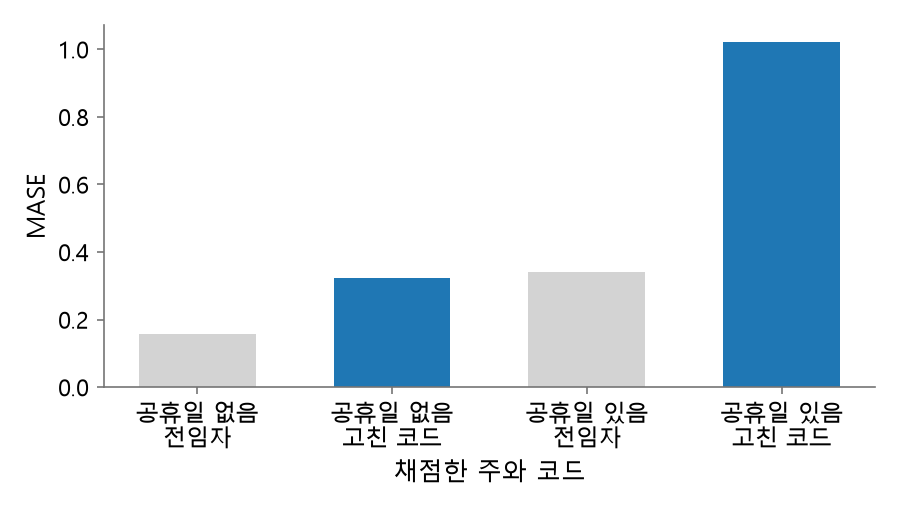

In [9]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다. 아래는 전임 담당자가 남긴 코드라 오류 없이 돌아가지만 운영에 쓸 수 없는 코드입니다.
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 튜터가 AI 코드 표시선 아래를 다시 씁니다.
# 고칠 지시는 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 대화창에만 쓰면 진단은 나오지만 완성본 풀이가 열리지 않습니다
PROMPT = """
전임 담당자의 코드 중 승차나 하차와 같이 과거 공변량이 있어서 데이터 누수가 있는 것 같아
내가 점검한 내용이 맞는지 알려주고 아래 출력물 관련 내용 확인 후 코드 작성해줘
1. future_df 공변량 열 수: 단위 개, 정수, 고친 future_df에서 item_id, timestamp를 뺀 열 수
2. 공휴일 있는 세 주 MASE 차(고친 코드 - 전임자 코드): 소수 셋째 자리, 고친 코드의 공휴일 있는 세 주 평균 MASE에서 전임자 코드 값을 뺀 값
3. 그래프
가로축: 채점한 주와 코드
세로축: MASE
공휴일 유무 X 두 코드의 막대 4개에 고친 코드만 다른 색으로 지정
"""
# --- 여기부터 AI 코드 ---
def mase_for(o, drop_alight):
    panel = panel_frame(o)                                   # 역·날짜·승차·공휴일·하차
    df = panel[panel["timestamp"] < pd.Timestamp(o)]
    future_df = panel[panel["timestamp"] >= pd.Timestamp(o)].drop(columns=["target"])
    if drop_alight:
        df = df.drop(columns=["alight"])
        future_df = future_df.drop(columns=["alight"])
    fc = PIPE.predict_df(df, future_df=future_df, prediction_length=H, quantile_levels=QS)
    return mase_of(o, fc), future_df

old = {o: mase_for(o, drop_alight=False)[0] for o in ORIGINS}
new = {}
for o in ORIGINS:
    new[o], fixed_future = mase_for(o, drop_alight=True)

n_cov = len([c for c in fixed_future.columns if c not in ("item_id", "timestamp")])
old_plain, old_hol = np.mean([old[o] for o in PLAIN_ORIGINS]), np.mean([old[o] for o in HOL_ORIGINS])
new_plain, new_hol = np.mean([new[o] for o in PLAIN_ORIGINS]), np.mean([new[o] for o in HOL_ORIGINS])

print(f"future_df 공변량 열 수 = {n_cov}")
print(f"공휴일 있는 세 주 MASE 차(고친 코드 − 전임자 코드) = {new_hol - old_hol:.3f}")
print(f"참고 | 공휴일 없는 두 주: 전임자 {old_plain:.3f} · 고친 코드 {new_plain:.3f} (제로샷 0.271)")
print(f"참고 | 공휴일 있는 세 주: 전임자 {old_hol:.3f} · 고친 코드 {new_hol:.3f}")

labels = ["공휴일 없음\n전임자", "공휴일 없음\n고친 코드", "공휴일 있음\n전임자", "공휴일 있음\n고친 코드"]
vals = [old_plain, new_plain, old_hol, new_hol]
colors = ["lightgray", "tab:blue", "lightgray", "tab:blue"]
fig, ax = plt.subplots(figsize=(FIG_W * 0.6, 3.4))
ax.bar(labels, vals, color=colors, width=0.6)
ax.set_xlabel("채점한 주와 코드"); ax.set_ylabel("MASE")
plt.show()